# Analyze of the light distribution

In [2]:
import pandas as pd
import tqdm
import numpy as np
import glob
from collections import defaultdict

def read_params(path):
    params = pd.read_csv(path, header=None, sep=" ", index_col=False, lineterminator='\n')
    params.rename(columns={0:'img_name'}, inplace=True)
    params = params.set_index('img_name').T.to_dict('list')
    return params

def swap_key(params):
    params_s = defaultdict(dict)
    for params_name, v in params.items():
        for img_name, params_value in v.items():
            params_s[img_name][params_name] = np.array(params_value).astype(np.float64)

    return params_s

def load_deca_params(deca_dir, cfg):
    deca_params = {}

    # face params 
    params_key = ['light']
    for k in tqdm.tqdm(params_key, desc="Loading deca params..."):
        params_path = glob.glob(f"{deca_dir}/*{k}-anno.txt")
        for path in params_path:
            deca_params[k] = read_params(path=path)
    
    deca_params = swap_key(deca_params)
    return deca_params

In [4]:
if False:
    import misc, os
    import torch as th
    from PIL import Image
    out_dir_wclip = '/data/mint/DPM_Dataset/ffhq_256_with_anno/ball/clip/train/'
    out_dir_woclip = '/data/mint/DPM_Dataset/ffhq_256_with_anno/ball/woclip/train/'
    os.makedirs(out_dir_wclip, exist_ok=True)
    os.makedirs(out_dir_woclip, exist_ok=True)
    for sh_k in tqdm.tqdm(sh.keys()):
        img_name = sh_k.split('/')[-1].split('.')[0]
        tmp_wclip, tmp_woclip = misc.drawSphere(sh=th.tensor(sh[sh_k]).view(9, 3))
        Image.fromarray((tmp_wclip.permute(1, 2, 0).cpu().numpy() * 255.).astype(np.uint8)).save(f'{out_dir_wclip}/{img_name}.png')
        tmp_wclip = tmp_wclip.permute(1, 2, 0).cpu().numpy()
        np.save(f'{out_dir_woclip}/{img_name}.npy', tmp_wclip)


In [ ]:
import misc, os
from PIL import Image
import torch as th
import matplotlib.pyplot as plt
import time

def compute_distance(inp_sh, ref_sh_img, img_name, dist_type='l2'):
    ref_sh_img = Image.open(ref_sh_img)
    inp_sh_img = inp_sh['ball']
    mask = inp_sh['mask']
    if dist_type == 'l2':
        # L2 pixel-wise distance with mask
        dist = np.mean(((inp_sh_img - ref_sh_img)**2) * mask)
    elif dist_type == 'l1':
        # L1 pixel-wise distance with mask
        dist = np.mean(np.abs(inp_sh_img - ref_sh_img) * mask)
    return {img_name : dist}

# multiprocess to compute distance
from multiprocessing import Pool
training_data = '/data/mint/DPM_Dataset/ffhq_256_with_anno/'
images = f'{training_data}/ffhq_256/train/'
# light_file = f'{training_data}/params/train/ffhq-train-light-anno.txt'
# training_sh = read_params(light_file)
training_sh = glob.glob('/data/mint/DPM_Dataset/ffhq_256_with_anno/ball/clip/train/*.png')

data = 'holo'
if data == 'holo':
    testing_lightfile = '/data/mint/DPM_Dataset/HoloRelighting/params/valid/ffhq-valid-light-anno.txt'
    testing_img_path = '/data/mint/DPM_Dataset/HoloRelighting/images_aligned/valid/'
    testing_sj = {'f4_main_ref_1':[], 'f6_sup_ref_1':[], 'f6_sup_ref_3':[]}
elif data == 'switch':
    testing_lightfile = '/data/mint/DPM_Dataset/SwitchLight/params/valid/ffhq-valid-light-anno.txt'
    testing_img_path = '/data/mint/DPM_Dataset/SwitchLight/images_aligned/valid/'
    testing_sj = {'fig7_main_ref_5':[], 'fig7_main_ref_6':[]}

testing_sh = read_params(testing_lightfile)
for k in testing_sj.keys():
    sh_k = k + '.png'
    tmp_wclip, tmp_woclip = misc.drawSphere(sh=th.tensor(testing_sh[sh_k]).view(9, 3))
    tmp_wclip = tmp_wclip.permute(1, 2, 0).cpu().numpy()
    ball = (tmp_wclip * 255.0).astype(np.uint8)
    testing_sj[k] = {
        'ball':ball,
        'mask': (ball > 0) * 1.0
    }

n_compute = 60000
os.makedirs('./imgs', exist_ok=True)
dist_type = 'l1'
ref_training_sh = training_sh[:n_compute]
for k in testing_sj.keys():
    start = time.time()
    with Pool(32) as p:
        dist_dict = p.starmap(compute_distance, [(testing_sj[k], ref_training_sh[i], ref_training_sh[i].split('/')[-1], dist_type) for i in range(0, len(ref_training_sh))])
    if dist_type == 'l2' or dist_type == 'l1':
        sorted_dist = sorted(dist_dict, key=lambda x: list(x.values())[0])
    
    # List of dict to dict
    sorted_dist = {list(d.keys())[0]: list(d.values())[0] for d in sorted_dist}
    
    # Show top n images in grid
    top_n = [Image.open(testing_img_path + k + '.png')]
    top_n_ball = [testing_sj[k]['ball']]
    n = 10
    i = 0
    for k, v in sorted_dist.items():
        img = Image.open(images + k.replace('.png', '.jpg'))
        top_n.append(img)
        top_n_ball.append(Image.open(f'/data/mint/DPM_Dataset/ffhq_256_with_anno/ball/clip/train/{k}'))
        if i == n:
            break
        i += 1

    top_n = np.concatenate(top_n, axis=1)
    top_n_ball = np.concatenate(top_n_ball, axis=1)
    vis_img = np.concatenate([top_n, top_n_ball], axis=0)
    Image.fromarray(vis_img).save(f'./imgs/{k}_{dist_type}_{data}.png')
    # plt.figure(figsize=(40, 40))
    # plt.imshow(vis_img)
    # plt.show()
    print(f"[#] Time taken: {time.time() - start}")
        

KeyboardInterrupt: 

# Using unclip rendered

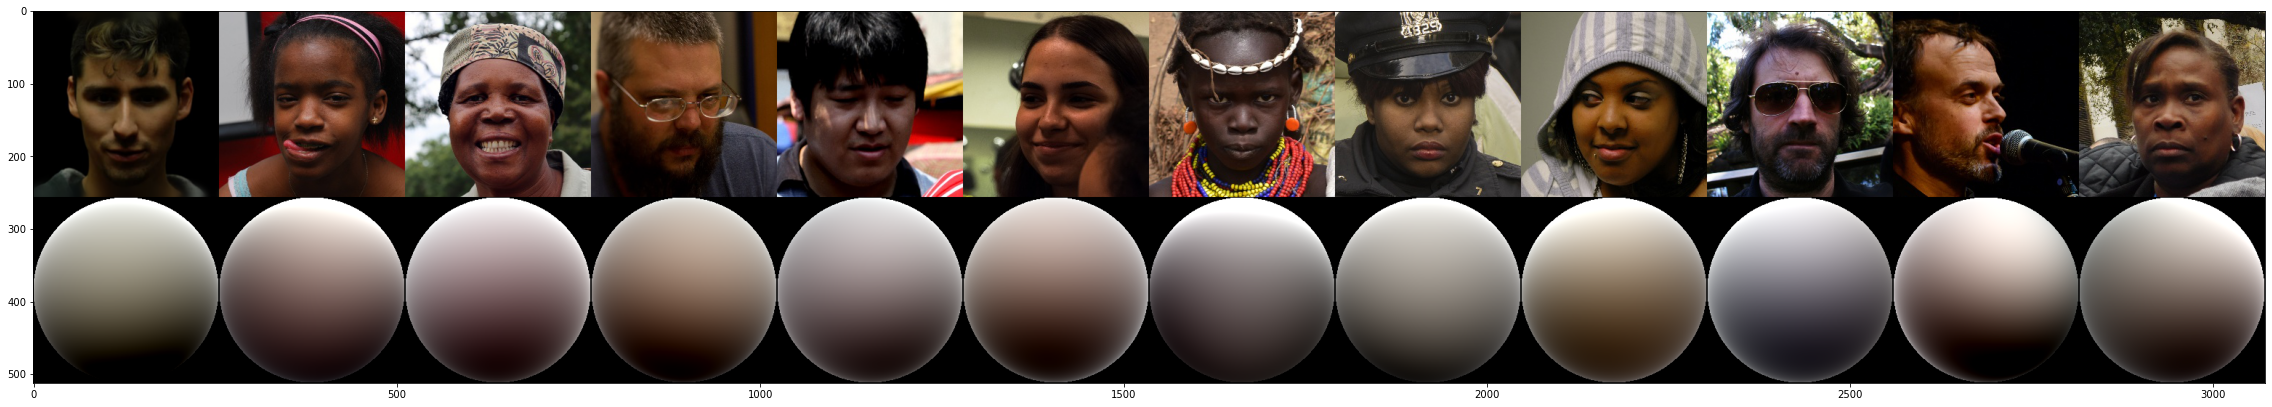

[#] Time taken: 690.5123083591461


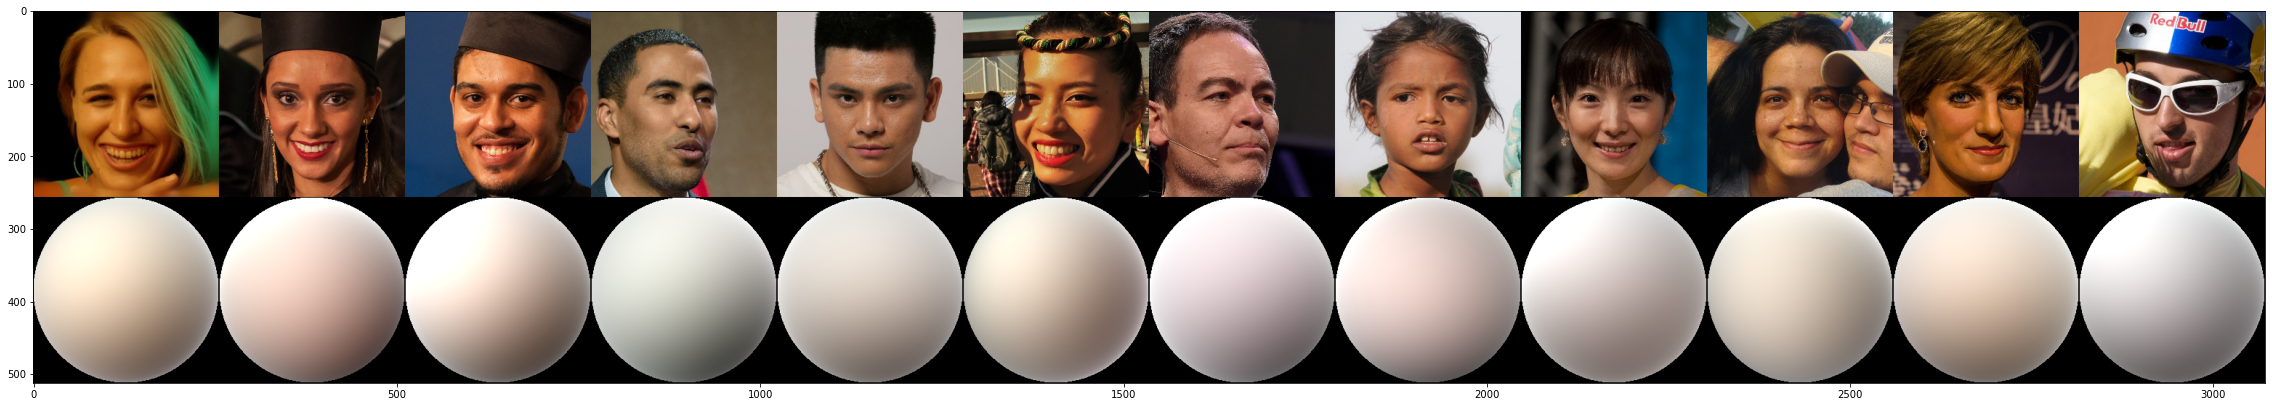

[#] Time taken: 609.9988086223602


In [ ]:
import misc, os
from PIL import Image
import torch as th
import matplotlib.pyplot as plt
import time

def compute_distance(inp_sh, ref_sh_img, img_name, dist_type='l2'):
    ref_sh_img = np.load(ref_sh_img)
    inp_sh_img = inp_sh['ball']
    mask = inp_sh['mask']
    if dist_type == 'l2':
        # L2 pixel-wise distance with mask
        dist = np.mean(((inp_sh_img - ref_sh_img)**2) * mask)
    elif dist_type == 'l1':
        # L1 pixel-wise distance with mask
        dist = np.mean(np.abs(inp_sh_img - ref_sh_img) * mask)
    return {img_name : dist}

# multiprocess to compute distance
from multiprocessing import Pool
training_data = '/data/mint/DPM_Dataset/ffhq_256_with_anno/'
images = f'{training_data}/ffhq_256/train/'
# light_file = f'{training_data}/params/train/ffhq-train-light-anno.txt'
# training_sh = read_params(light_file)
training_sh = glob.glob('/data/mint/DPM_Dataset/ffhq_256_with_anno/ball/woclip/train/*.npy')

data = 'holo'
# data = 'switch'
if data == 'holo':
    testing_lightfile = '/data/mint/DPM_Dataset/HoloRelighting/params/valid/ffhq-valid-light-anno.txt'
    testing_img_path = '/data/mint/DPM_Dataset/HoloRelighting/images_aligned/valid/'
    testing_sj = {'f4_main_ref_1':[], 'f6_sup_ref_1':[], 'f6_sup_ref_3':[]}
elif data == 'switch':
    testing_lightfile = '/data/mint/DPM_Dataset/SwitchLight/params/valid/ffhq-valid-light-anno.txt'
    testing_img_path = '/data/mint/DPM_Dataset/SwitchLight/images_aligned/valid/'
    testing_sj = {'fig7_main_ref_5':[], 'fig7_main_ref_6':[]}

testing_sh = read_params(testing_lightfile)
for k in testing_sj.keys():
    sh_k = k + '.png'
    tmp_wclip, tmp_woclip = misc.drawSphere(sh=th.tensor(testing_sh[sh_k]).view(9, 3))
    tmp_wclip = tmp_wclip.permute(1, 2, 0).cpu().numpy()
    tmp_woclip = tmp_woclip.permute(1, 2, 0).cpu().numpy()

    # ball = (tmp_wclip * 255.0).astype(np.uint8)
    ball = tmp_woclip
    testing_sj[k] = {
        'ball':ball,
        # 'mask': (ball > 0) * 1.0
        'mask': (ball * 0.0) + 1.0
    }
    # print(ball.max(), ball.min())
    # assert False

n_compute = 60000
os.makedirs('./npy', exist_ok=True)
dist_type = 'l2'
ref_training_sh = training_sh[:n_compute]
for k in testing_sj.keys():
    start = time.time()
    with Pool(32) as p:
        dist_dict = p.starmap(compute_distance, [(testing_sj[k], ref_training_sh[i], ref_training_sh[i].split('/')[-1], dist_type) for i in range(0, len(ref_training_sh))])
    if dist_type == 'l2' or dist_type == 'l1':
        sorted_dist = sorted(dist_dict, key=lambda x: list(x.values())[0])
    
    # List of dict to dict
    sorted_dist = {list(d.keys())[0]: list(d.values())[0] for d in sorted_dist}

    top_n = [Image.open(testing_img_path + k + '.png')]
    top_n_ball = [(np.clip(testing_sj[k]['ball'], 0, 1) * 255).astype(np.uint8)]
    n = 10
    i = 0
    for kk, v in sorted_dist.items():
        img = Image.open(images + kk.replace('.npy', '.jpg'))
        top_n.append(img)
        ball_tmp = np.load(f'/data/mint/DPM_Dataset/ffhq_256_with_anno/ball/woclip/train/{kk}')
        ball_tmp = (np.clip(ball_tmp, 0, 1) * 255).astype(np.uint8)
        top_n_ball.append(ball_tmp)
        if i == n:
            break
        i += 1

    top_n = np.concatenate(top_n, axis=1)
    top_n_ball = np.concatenate(top_n_ball, axis=1)
    vis_img = np.concatenate([top_n, top_n_ball], axis=0)
    Image.fromarray(vis_img).save(f'./npy/{k}_{dist_type}_{data}.png')
    plt.figure(figsize=(40, 40))
    plt.imshow(vis_img)
    plt.show()
    print(f"[#] Time taken: {time.time() - start}")